# Uniaxial Plasticity

This notebook investigates uniaxial plasticity models that are included in OpenSees/Xara.


In [1]:
from numpy import sin, linspace, pi
import numpy as np
from utilities import mark_slope
import matplotlib.pyplot as plt

For convenience, import unit constants from the {ref}`units` submodule and define parameters.

In [2]:
from xara.units.english import ksi, psi

Fy  = 66.8*ksi             # steel yield stress
Es  = 29000.*ksi           # modulus of steel

Next, create the {py:class}`xara.UniaxialMaterial`.

In [3]:
import xara 

plastic_material = xara.UniaxialMaterial("Hardening", E=Es, Fy=Fy, Hiso=0)


strain = 0.005*sin(linspace(0, 2.0*pi, 100))

stress = []
with plastic_material as tmp:

    for e in strain:
        stress.append(tmp.getStress(e, commit=True)/Fy)


Now that the stress and strain are stored, the can be plotted using `matplotlib`

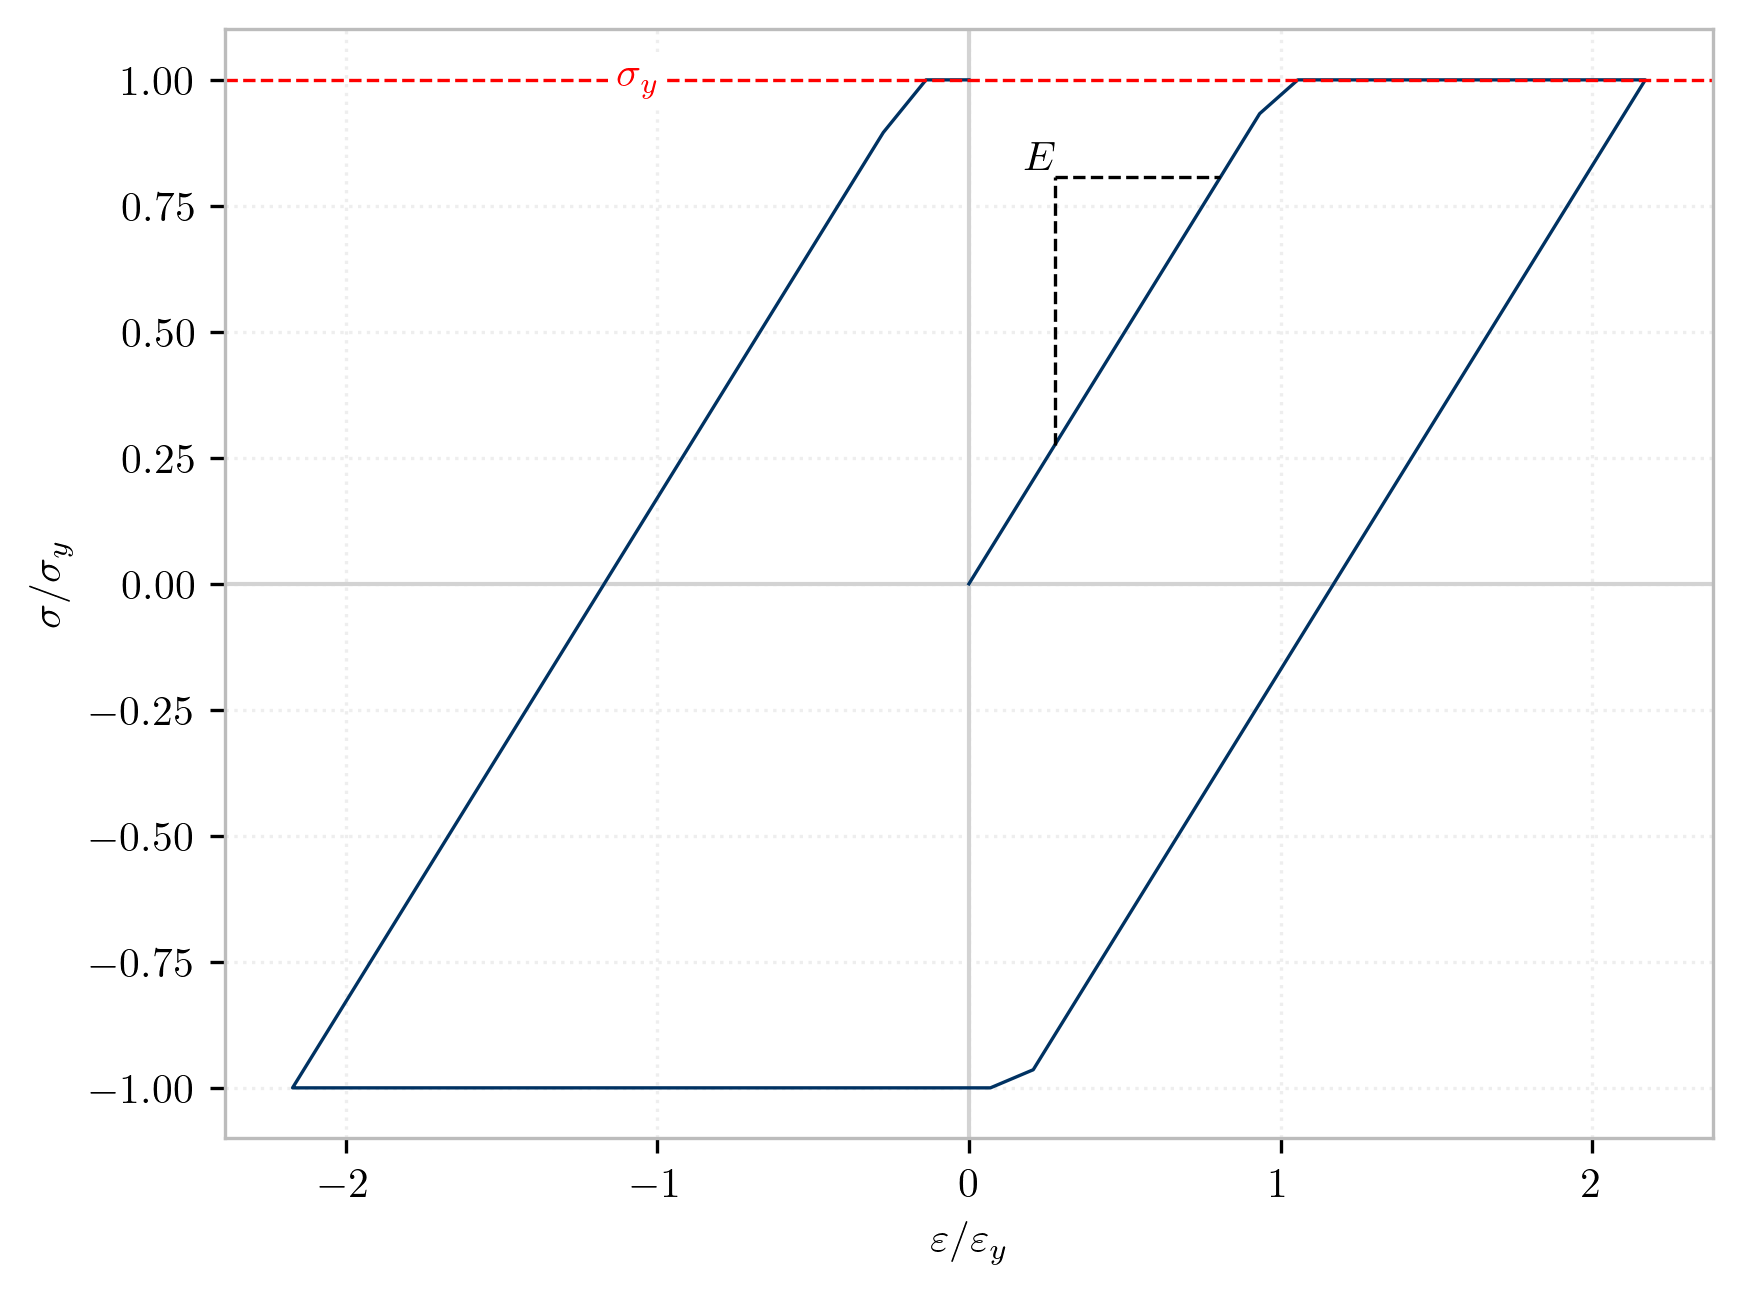

In [4]:

# create a plotting figure
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)
ln = ax.plot(strain/(Fy/Es), stress)

mark_slope(ax, ln[0], 0.25, 0.75, iend=20, label="$E$", color='k', ls='--')
ax.axhline(y=1, color='r', linestyle='--')
ax.text(-1, 1, r"$\sigma_y$", color='r', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/\sigma_y$");

Now create two instances of ``Steel02`` with differing values for the `R0` parameter:

In [ ]:

steel_material = xara.UniaxialMaterial("Steel02", E=Es, Fy=Fy, R0=5, b=0.05)

steel_material_20 = xara.UniaxialMaterial("Steel02", E=Es, Fy=Fy, R0=20, b=0.05)


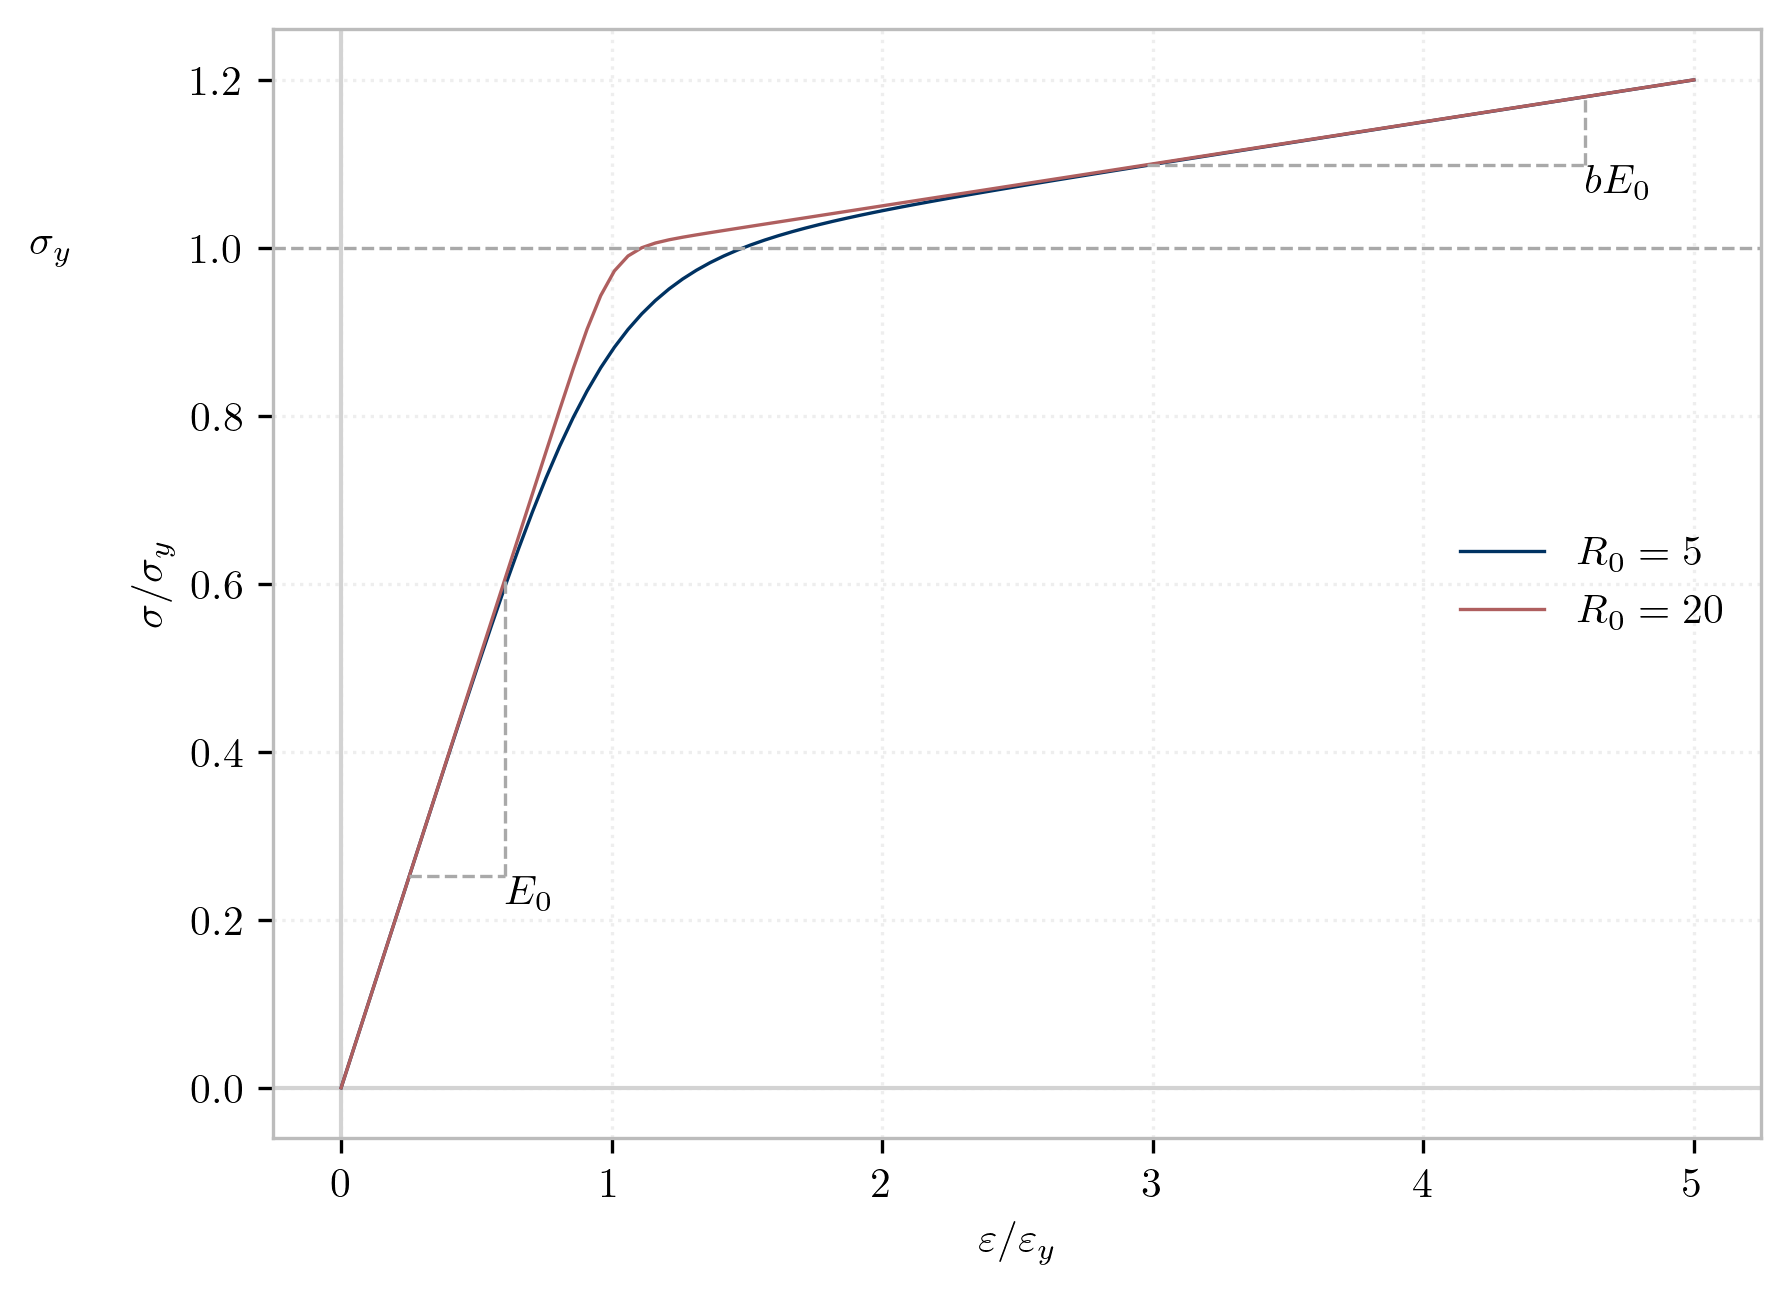

In [ ]:
fig, ax = plt.subplots()
ax.axhline(0, color='lightgrey', linestyle='-', linewidth=1)
ax.axvline(0, color='lightgrey', linestyle='-', linewidth=1)

strain = np.linspace(0, Fy/Es*5, 100)

with steel_material as tmp:
    ln = ax.plot(strain/(Fy/Es), 
                 [tmp.getStress(e, commit=True)/Fy for e in strain],
                 label="$R_0=5$")


with steel_material_20 as tmp:
    ln = ax.plot(strain/(Fy/Es), 
                 [tmp.getStress(e, commit=True)/Fy for e in strain],
                 label="$R_0=20$")

mark_slope(ax, ln[0], 0.25, 0.60, label="$E_0$", color='darkgrey', loc="right", ls='--')
mark_slope(ax, ln[0], 1.1, 1.18, label="$b E_0$", color='darkgrey', loc="right", ls='--')

# Draw a horizontal line at the yield stress Fy
ax.axhline(y=1, color='darkgrey', linestyle='--')
ax.text(-1, 1, r"$\sigma_y$", color='k', va='center', ha='right', bbox=dict(facecolor='white', edgecolor='none', pad=2.0))

ax.set_xlabel(r"$\varepsilon/\varepsilon_y$")
ax.set_ylabel(r"$\sigma/\sigma_y$")
ax.legend();